# Statistical Comparison

**Thesis:** Predicting Agentic Pull Request Rejection: An Empirical Comparison of NLP Approaches  

**Author:** Victoria Angela Vizmonte  

This notebook runs all cross-model statistical tests reported in the thesis. It loads the held-out test predictions from all three models, verifies PR-ID alignment across prediction files, computes 95% bootstrap confidence intervals on PR-AUC, runs pairwise bootstrap significance tests and McNemar's tests on binary predictions, and applies Holm-Bonferroni correction across all pairwise comparisons. All results are saved to `results/final/statistical_tests/`.

---

| Item | Value |
|---|---|
| Models compared | Multimodal LR, Few-Shot Standard LLM (Qwen3-32B), Few-Shot Reasoning LLM (QwQ-32B) |
| Test set size | 1,597 PRs (562 rejected, 1,035 accepted) |
| Primary metric | PR-AUC (rejection class) |
| CI method | Paired bootstrap, n=10,000 resamples, seed=42 |
| Significance level | α=0.05 |
| Multiple comparisons | Holm-Bonferroni correction (bootstrap + McNemar p-values combined) |
| Results output | `results/final/statistical_tests/` |

In [2]:
# ---------------------------------------------------------------
# CONFIGURE THIS PATH before running any other cell.
# Set DRIVE_BASE to the folder on your Google Drive that contains
# data/, src/, results/, and requirements.txt for this project.
# Example: if you placed the shared folder at the root of your
# Drive, set this to '/content/drive/MyDrive/AgenticPRRejection'
# ---------------------------------------------------------------

from google.colab import drive
import subprocess, sys
from pathlib import Path

DRIVE_BASE = Path('/content/drive/MyDrive/Thesis/AgenticPRRejection')   # replace with your own path

drive.mount('/content/drive')
print('Drive mounted')

sys.path.insert(0, f'{DRIVE_BASE}/src')
print('src/ added to path')

subprocess.run(
    ['pip', 'install', '-q', '-r',
     f'{DRIVE_BASE}/requirements.txt'],
    check=True
)
print('Dependencies installed')

Mounted at /content/drive
Drive mounted
src/ added to path
Dependencies installed


In [3]:
# Imports and configuration
import json as _json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from statsmodels.stats.contingency_tables import mcnemar
from statsmodels.stats.multitest import multipletests

from statistical_tests import bootstrap_pr_auc_ci, bootstrap_pairwise_test

DRIVE_BASE = Path(DRIVE_BASE)
print(f'DRIVE_BASE set to: {DRIVE_BASE}')
print(f'Exists on Drive:   {DRIVE_BASE.exists()}')
RESULTS_BASE = DRIVE_BASE / 'results' / 'final'
OUTPUT_DIR = DRIVE_BASE / 'results' / 'final' / 'statistical_tests'
SEED = 42
N_BOOTSTRAP = 10000
ALPHA = 0.05

METRICS_PATHS = {
    'Multimodal LR': str(RESULTS_BASE / 'multimodal_lr' / 'multimodal_lr_metrics.json'),
    'Qwen3 Standard LLM': str(RESULTS_BASE / 'qwen3_standard_llm' / 'qwen3_standard_llm_metrics.json'),
    'QwQ Reasoning LLM':  str(RESULTS_BASE / 'qwq_reasoning_llm' / 'qwq_reasoning_llm_metrics.json'),
}

MODEL_CONFIG = {
    'Multimodal LR': {
        'csv_path': str(RESULTS_BASE / 'multimodal_lr' / 'multimodal_lr_predictions_test.csv'),
        'pr_id_col': 'pr_id',
        'score_col': 'rejection_probability',
    },
    'Qwen3 Standard LLM': {
        'csv_path': str(RESULTS_BASE / 'qwen3_standard_llm' / 'qwen3_standard_llm_predictions_test.csv'),
        'pr_id_col': 'pr_id',
        'score_col': 'rejection_probability',
    },
    'QwQ Reasoning LLM': {
        'csv_path': str(RESULTS_BASE / 'qwq_reasoning_llm' / 'qwq_reasoning_llm_predictions_test.csv'),
        'pr_id_col': 'pr_id',
        'score_col': 'rejection_probability',
    },
}

print('Configuration ready.')

DRIVE_BASE set to: /content/drive/MyDrive/Thesis/AgenticPRRejection
Exists on Drive:   True
Configuration ready.


In [4]:
# Load predictions
model_dfs = {}

for model_name, cfg in MODEL_CONFIG.items():
    df = pd.read_csv(cfg['csv_path'])
    df = df.rename(columns={cfg['score_col']: 'score', cfg['pr_id_col']: 'pr_id'})
    df = df[['pr_id', 'label', 'score', 'y_pred']].copy()
    model_dfs[model_name] = df
    print(f'{model_name}: shape={df.shape}')
    print(df.head(3).to_string(index=False))
    print()

Multimodal LR: shape=(1597, 4)
     pr_id  label  score  y_pred
3226617976      0 0.3862       0
3226629281      0 0.2863       0
3226644014      1 0.6157       1

Qwen3 Standard LLM: shape=(1597, 4)
     pr_id  label  score  y_pred
3226617976      0 0.4567       0
3226629281      0 0.2341       0
3226644014      1 0.3471       0

QwQ Reasoning LLM: shape=(1597, 4)
     pr_id  label  score  y_pred
3226617976      0 0.6892       1
3226629281      0 0.1234       0
3226644014      1 0.0672       0



In [5]:
# Alignment check
model_names = list(model_dfs.keys())

merged = model_dfs[model_names[0]][['pr_id', 'label', 'score']].rename(
    columns={'label': f'label_{model_names[0]}', 'score': f'score_{model_names[0]}'}
)
for name in model_names[1:]:
    right = model_dfs[name][['pr_id', 'label', 'score']].rename(
        columns={'label': f'label_{name}', 'score': f'score_{name}'}
    )
    merged = merged.merge(right, on='pr_id', how='inner')

EXPECTED_ROWS = 1597

errors = []

if len(merged) != EXPECTED_ROWS:
    errors.append(
        f'Expected {EXPECTED_ROWS} rows after inner join, got {len(merged)}. '
        'Check for missing pr_ids across prediction files.'
    )
    pr_id_sets = {name: set(model_dfs[name]['pr_id']) for name in model_names}
    ref_ids = pr_id_sets[model_names[0]]
    for name in model_names[1:]:
        missing = ref_ids.symmetric_difference(pr_id_sets[name])
        if missing:
            print(f'pr_ids not shared between {model_names[0]} and {name}: {sorted(missing)[:20]}')

label_col_0 = f'label_{model_names[0]}'
for name in model_names[1:]:
    label_col = f'label_{name}'
    mismatch = merged[merged[label_col_0] != merged[label_col]]
    if len(mismatch) > 0:
        errors.append(
            f'Label mismatch between {model_names[0]} and {name}: {len(mismatch)} rows differ.'
        )
        print(mismatch[['pr_id', label_col_0, label_col]].head(10).to_string(index=False))

null_counts = merged.isnull().sum()
null_cols = null_counts[null_counts > 0]
if len(null_cols) > 0:
    errors.append(f'Null values found after merge:\n{null_cols.to_string()}')

if errors:
    raise ValueError('Alignment check failed:\n' + '\n'.join(errors))

y_true = merged[label_col_0].to_numpy()
n_rejected = int(y_true.sum())
n_accepted = int(len(y_true) - n_rejected)
rejection_rate = n_rejected / len(y_true)

print(f'Alignment check passed.')
print(f'  n rows:         {len(merged)}')
print(f'  n accepted:     {n_accepted}')
print(f'  n rejected:     {n_rejected}')
print(f'  rejection rate: {rejection_rate:.4f}')

Alignment check passed.
  n rows:         1597
  n accepted:     1035
  n rejected:     562
  rejection rate: 0.3519


## Per-model Bootstrap CIs on PR-AUC

In [6]:
# Per-model bootstrap CIs on PR-AUC
ci_rows = []

for model_name in model_names:
    y_score = merged[f'score_{model_name}'].to_numpy()
    result = bootstrap_pr_auc_ci(
        y_true=y_true,
        y_score=y_score,
        n_bootstrap=N_BOOTSTRAP,
        alpha=ALPHA,
        seed=SEED,
    )
    # Load authoritative point estimate from metrics.json (avoids CSV float precision loss)
    with open(METRICS_PATHS[model_name]) as fh:
        pr_auc_point = _json.load(fh)['test']['auc_pr']
    ci_rows.append({
        'model': model_name,
        'pr_auc_point': pr_auc_point,
        'ci_lower': result['ci_lower'],
        'ci_upper': result['ci_upper'],
    })

ci_results = pd.DataFrame(ci_rows)
print(ci_results.to_string(index=False, float_format='%.4f'))

             model  pr_auc_point  ci_lower  ci_upper
     Multimodal LR        0.5309    0.4902    0.5761
Qwen3 Standard LLM        0.4242    0.3873    0.4670
 QwQ Reasoning LLM        0.4359    0.3973    0.4775


## Pairwise Bootstrap Tests

In [7]:
# Pairwise bootstrap tests
pairs = [
    ('Multimodal LR', 'Qwen3 Standard LLM'),
    ('Multimodal LR', 'QwQ Reasoning LLM'),
    ('Qwen3 Standard LLM', 'QwQ Reasoning LLM'),
]

pairwise_rows = []

for model_a, model_b in pairs:
    scores_a = merged[f'score_{model_a}'].to_numpy()
    scores_b = merged[f'score_{model_b}'].to_numpy()
    result = bootstrap_pairwise_test(
        y_true=y_true,
        scores_a=scores_a,
        scores_b=scores_b,
        n_bootstrap=N_BOOTSTRAP,
        alpha=ALPHA,
        seed=SEED,
    )
    pairwise_rows.append({
        'model_a': model_a,
        'model_b': model_b,
        'delta_pr_auc': result['observed_diff'],
        'p_value': result['p_value'],
        'significant': result['significant'],
        'delta_ci_lower': result['ci_lower'],
        'delta_ci_upper': result['ci_upper'],
    })

pairwise_results = pd.DataFrame(pairwise_rows)
print(pairwise_results.to_string(index=False, float_format='%.4f'))

           model_a            model_b  delta_pr_auc  p_value  significant  delta_ci_lower  delta_ci_upper
     Multimodal LR Qwen3 Standard LLM        0.1066   0.0000         True          0.0575          0.1543
     Multimodal LR  QwQ Reasoning LLM        0.0950   0.0001         True          0.0458          0.1458
Qwen3 Standard LLM  QwQ Reasoning LLM       -0.0116   0.4490        False         -0.0408          0.0197


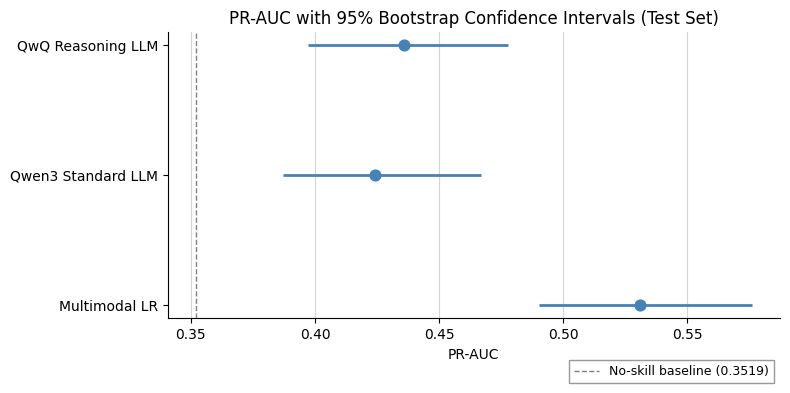

Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/ci_plot_pr_auc.pdf


In [8]:
# CI plot: PR-AUC point estimates with 95% bootstrap confidence intervals
DISPLAY_LABELS = {
    'Multimodal LR': 'Multimodal LR',
    'Qwen3 Standard LLM': 'Qwen3 Standard LLM',
    'QwQ Reasoning LLM':  'QwQ Reasoning LLM',
}
no_skill = float(y_true.sum()) / len(y_true)

plot_order = ['Multimodal LR', 'Qwen3 Standard LLM', 'QwQ Reasoning LLM']
plot_df = ci_results.set_index('model').loc[plot_order].reset_index()

y_positions = list(range(len(plot_order)))
y_labels = [DISPLAY_LABELS[m] for m in plot_order]

fig, ax = plt.subplots(figsize=(8, 4))
fig.subplots_adjust(bottom=0.2)

ax.hlines(
    y=y_positions,
    xmin=plot_df['ci_lower'],
    xmax=plot_df['ci_upper'],
    colors='steelblue',
    linewidths=2,
)
ax.scatter(
    plot_df['pr_auc_point'],
    y_positions,
    color='steelblue',
    s=60,
    zorder=3,
)

ax.axvline(no_skill, linestyle='--', color='grey', linewidth=1, label=f'No-skill baseline ({no_skill:.4f})')
ax.legend(loc='lower right', bbox_to_anchor=(1.0, -0.25), ncol=1, frameon=True, edgecolor='grey', fancybox=False, fontsize=9)

ax.set_yticks(y_positions)
ax.set_yticklabels(y_labels)
ax.set_xlabel('PR-AUC')
ax.set_title('PR-AUC with 95% Bootstrap Confidence Intervals (Test Set)')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.xaxis.grid(True, color='lightgrey', linewidth=0.8)
ax.set_axisbelow(True)

fig.tight_layout()

ci_plot_pdf = os.path.join(OUTPUT_DIR, 'ci_plot_pr_auc.pdf')
fig.savefig(ci_plot_pdf, bbox_inches='tight')
plt.show()
print(f'Saved: {ci_plot_pdf}')

## Cross-model PR-AUC comparison

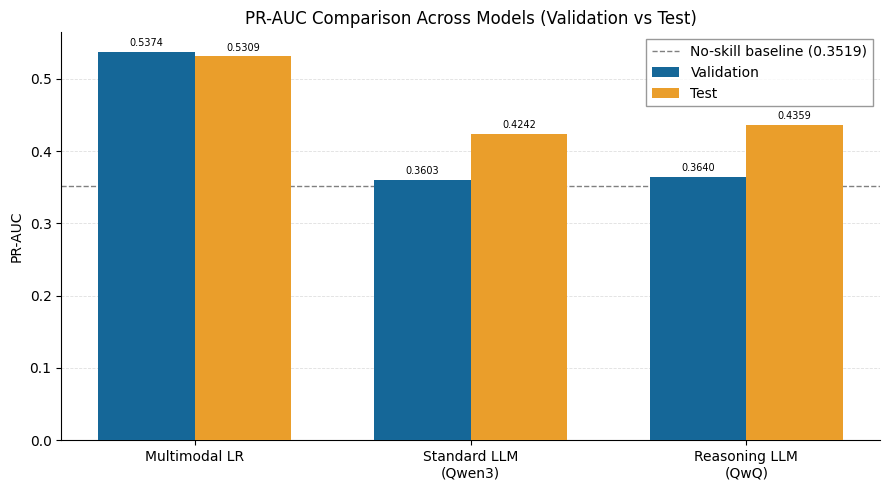

Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/bar_chart_pr_auc.pdf


In [9]:
# Bar chart: PR-AUC comparison across all models, val vs test
CATEGORICAL_PALETTE = [
    "#156798", "#ea9e2b", "#a45a25", "#939e47",
    "#d0a731", "#723e46", "#357768", "#2290bf",
]

VAL_COLOR  = CATEGORICAL_PALETTE[0]
TEST_COLOR = CATEGORICAL_PALETTE[1]

BAR_DISPLAY_LABELS = {
    "Multimodal LR": "Multimodal LR",
    "Qwen3 Standard LLM": "Standard LLM\n(Qwen3)",
    "QwQ Reasoning LLM":  "Reasoning LLM\n(QwQ)",
}

plot_order = ["Multimodal LR", "Qwen3 Standard LLM", "QwQ Reasoning LLM"]

val_scores, test_scores = [], []
for key in plot_order:
    with open(METRICS_PATHS[key]) as fh:
        m = _json.load(fh)
    val_scores.append(m["val"]["auc_pr"])
    test_scores.append(m["test"]["auc_pr"])

x = np.arange(len(plot_order))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars_val  = ax.bar(x - bar_width / 2, val_scores,  bar_width, color=VAL_COLOR,  label="Validation", zorder=3)
bars_test = ax.bar(x + bar_width / 2, test_scores, bar_width, color=TEST_COLOR, label="Test",       zorder=3)

ax.axhline(
    rejection_rate,
    linestyle="--",
    color="grey",
    linewidth=1,
    label=f"No-skill baseline ({rejection_rate:.4f})",
    zorder=2,
)

for bar, val in zip(bars_val, val_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=7,
    )
for bar, val in zip(bars_test, test_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{val:.4f}",
        ha="center", va="bottom", fontsize=7,
    )

ax.set_xticks(x)
ax.set_xticklabels([BAR_DISPLAY_LABELS[m] for m in plot_order])
ax.set_ylim(bottom=0)
ax.set_ylabel("PR-AUC")
ax.set_title("PR-AUC Comparison Across Models (Validation vs Test)")
ax.yaxis.grid(True, linestyle="--", linewidth=0.6, alpha=0.4, zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(loc="upper right", frameon=True, edgecolor="grey", fancybox=False)

fig.tight_layout()

bar_chart_pdf = os.path.join(OUTPUT_DIR, "bar_chart_pr_auc.pdf")
fig.savefig(bar_chart_pdf)
plt.show()
print(f"Saved: {bar_chart_pdf}")

In [10]:
# Save results
os.makedirs(OUTPUT_DIR, exist_ok=True)

ci_path = os.path.join(OUTPUT_DIR, 'ci_results.csv')
pairwise_path = os.path.join(OUTPUT_DIR, 'pairwise_results.csv')

ci_results.to_csv(ci_path, index=False)
pairwise_results.to_csv(pairwise_path, index=False)

print(f'Saved: {ci_path}')
print(f'Saved: {pairwise_path}')

Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/ci_results.csv
Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/pairwise_results.csv


## Pairwise McNemar Tests

In [11]:
# Pairwise McNemar tests
pairs = [
    ('Multimodal LR', 'Qwen3 Standard LLM'),
    ('Multimodal LR', 'QwQ Reasoning LLM'),
    ('Qwen3 Standard LLM', 'QwQ Reasoning LLM'),
]

mcnemar_rows = []

for model_a, model_b in pairs:
    df_a = model_dfs[model_a][['pr_id', 'label', 'y_pred']].rename(columns={'y_pred': 'y_pred_a'})
    df_b = model_dfs[model_b][['pr_id', 'y_pred']].rename(columns={'y_pred': 'y_pred_b'})
    aligned = df_a.merge(df_b, on='pr_id', how='inner')

    correct_a = (aligned['y_pred_a'] == aligned['label']).astype(int)
    correct_b = (aligned['y_pred_b'] == aligned['label']).astype(int)

    # b: a correct, b wrong; c: a wrong, b correct
    b = int(((correct_a == 1) & (correct_b == 0)).sum())
    c = int(((correct_a == 0) & (correct_b == 1)).sum())

    use_exact = min(b, c) < 25
    test_type = 'exact' if use_exact else 'chi2'
    print(f'{model_a} vs {model_b}: b={b}, c={c} -> using {test_type}')

    # McNemar only uses b and c; concordant cells are irrelevant
    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=use_exact)

    mcnemar_rows.append({
        'model_a': model_a,
        'model_b': model_b,
        'n_b': b,
        'n_c': c,
        'statistic': result.statistic,
        'p_value': result.pvalue,
        'significant': result.pvalue < ALPHA,
        'test_type': test_type,
    })

mcnemar_results = pd.DataFrame(mcnemar_rows)
print(mcnemar_results.to_string(index=False, float_format='%.4f'))

mcnemar_path = os.path.join(OUTPUT_DIR, 'mcnemar_results.csv')
mcnemar_results.to_csv(mcnemar_path, index=False)
print(f'Saved: {mcnemar_path}')

Multimodal LR vs Qwen3 Standard LLM: b=377, c=309 -> using chi2
Multimodal LR vs QwQ Reasoning LLM: b=398, c=333 -> using chi2
Qwen3 Standard LLM vs QwQ Reasoning LLM: b=162, c=165 -> using chi2
           model_a            model_b  n_b  n_c  statistic  p_value  significant test_type
     Multimodal LR Qwen3 Standard LLM  377  309     6.5437   0.0105         True      chi2
     Multimodal LR  QwQ Reasoning LLM  398  333     5.6033   0.0179         True      chi2
Qwen3 Standard LLM  QwQ Reasoning LLM  162  165     0.0122   0.9119        False      chi2
Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/mcnemar_results.csv


## Holm-Bonferroni correction

In [12]:
# Holm-Bonferroni correction across all pairwise p-values
bootstrap_rows = pairwise_results[['model_a', 'model_b', 'p_value', 'significant']].copy()
bootstrap_rows['test_type'] = 'Bootstrap_PR_AUC'

mcnemar_rows_holm = mcnemar_results[['model_a', 'model_b', 'p_value', 'significant']].copy()
mcnemar_rows_holm['test_type'] = 'McNemar'

all_tests = pd.concat([bootstrap_rows, mcnemar_rows_holm], ignore_index=True)
all_p_values = all_tests['p_value'].to_numpy()

reject, p_corrected, _, _ = multipletests(all_p_values, alpha=ALPHA, method='holm')

all_tests['p_value_raw'] = all_p_values
all_tests['p_value_corrected'] = p_corrected
all_tests['significant_raw'] = all_tests['significant']
all_tests['significant_corrected'] = reject
all_tests = all_tests.drop(columns=['p_value', 'significant'])

cols = ['model_a', 'model_b', 'test_type', 'p_value_raw', 'p_value_corrected',
        'significant_raw', 'significant_corrected']
holm_results = all_tests[cols]

print(holm_results.to_string(index=False, float_format='%.4f'))

n_sig_raw = int(holm_results['significant_raw'].sum())
n_sig_corrected = int(holm_results['significant_corrected'].sum())
print(f'\nBefore Holm correction: {n_sig_raw}/6 comparisons significant')
print(f'After Holm correction:  {n_sig_corrected}/6 comparisons significant')

holm_path = os.path.join(OUTPUT_DIR, 'holm_corrected_results.csv')
holm_results.to_csv(holm_path, index=False)
print(f'Saved: {holm_path}')

           model_a            model_b        test_type  p_value_raw  p_value_corrected  significant_raw  significant_corrected
     Multimodal LR Qwen3 Standard LLM Bootstrap_PR_AUC       0.0000             0.0000             True                   True
     Multimodal LR  QwQ Reasoning LLM Bootstrap_PR_AUC       0.0001             0.0005             True                   True
Qwen3 Standard LLM  QwQ Reasoning LLM Bootstrap_PR_AUC       0.4490             0.8980            False                  False
     Multimodal LR Qwen3 Standard LLM          McNemar       0.0105             0.0421             True                   True
     Multimodal LR  QwQ Reasoning LLM          McNemar       0.0179             0.0538             True                  False
Qwen3 Standard LLM  QwQ Reasoning LLM          McNemar       0.9119             0.9119            False                  False

Before Holm correction: 4/6 comparisons significant
After Holm correction:  3/6 comparisons significant
Saved:

## LLM Classifier Side-by-side Comparison

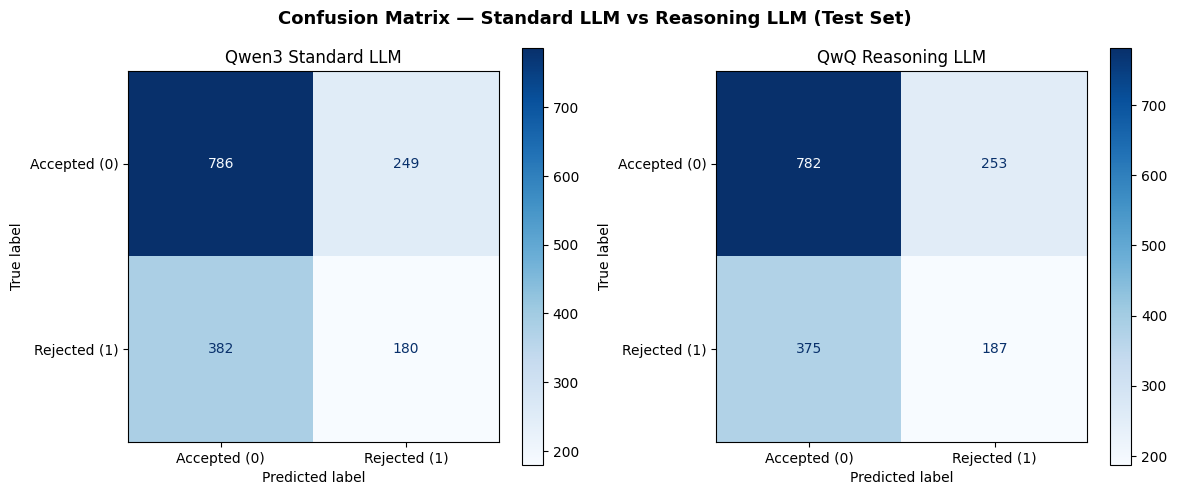

Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/confusion_matrix_comparison_test.pdf


In [13]:
# Side-by-side confusion matrices: Standard LLM vs Reasoning LLM (Test Set)
df_m3 = model_dfs['Qwen3 Standard LLM']
df_m4 = model_dfs['QwQ Reasoning LLM']

fig, (ax_m3, ax_m4) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Confusion Matrix — Standard LLM vs Reasoning LLM (Test Set)", fontsize=13, fontweight="bold")

for ax, df, label in [
    (ax_m3, df_m3, "Qwen3 Standard LLM"),
    (ax_m4, df_m4, "QwQ Reasoning LLM"),
]:
    cm = confusion_matrix(df['label'], df['y_pred'])
    ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Accepted (0)", "Rejected (1)"]
    ).plot(ax=ax, colorbar=True, cmap="Blues")
    ax.set_title(label)

fig.tight_layout()
cm_path = os.path.join(OUTPUT_DIR, "confusion_matrix_comparison_test.pdf")
fig.savefig(cm_path)
plt.show()
print(f"Saved: {cm_path}")

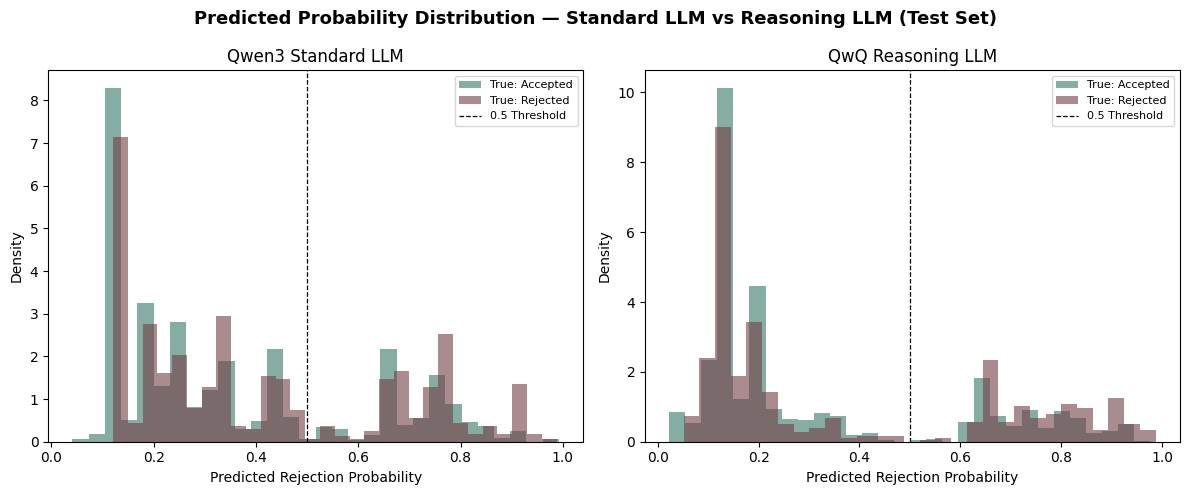

Saved: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/statistical_tests/prob_dist_comparison_test.pdf


In [14]:
# Side-by-side predicted probability distributions: Standard LLM vs Reasoning LLM (Test Set)
ACCEPTED_COLOR = "#357768"
REJECTED_COLOR = "#723e46"

df_m3 = model_dfs['Qwen3 Standard LLM']
df_m4 = model_dfs['QwQ Reasoning LLM']

fig, (ax_m3, ax_m4) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Predicted Probability Distribution — Standard LLM vs Reasoning LLM (Test Set)", fontsize=13, fontweight="bold")

for ax, df, label in [
    (ax_m3, df_m3, "Qwen3 Standard LLM"),
    (ax_m4, df_m4, "QwQ Reasoning LLM"),
]:
    mask_accepted = df['label'] == 0
    mask_rejected = df['label'] == 1
    ax.hist(df.loc[mask_accepted, 'score'], bins=30, alpha=0.6, color=ACCEPTED_COLOR, label="True: Accepted", density=True)
    ax.hist(df.loc[mask_rejected, 'score'], bins=30, alpha=0.6, color=REJECTED_COLOR, label="True: Rejected", density=True)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=0.9, label="0.5 Threshold")
    ax.set_xlabel("Predicted Rejection Probability")
    ax.set_ylabel("Density")
    ax.set_title(label)
    ax.legend(loc="upper right", fontsize=8)

fig.tight_layout()
prob_path = os.path.join(OUTPUT_DIR, "prob_dist_comparison_test.pdf")
fig.savefig(prob_path)
plt.show()
print(f"Saved: {prob_path}")